In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick

print(f'Versión de pandas: {pd.__version__}')
print(f'Versión de numpy: {np.__version__}')
print(f'Versión de scikit-learn (sklearn): {sklearn.__version__}')
print(f'Versión de seaborn: {sns.__version__}')
print(f'Versión de yellowbrick: {yellowbrick.__version__}')

Versión de pandas: 2.2.3
Versión de numpy: 2.2.5
Versión de scikit-learn (sklearn): 1.6.1
Versión de seaborn: 0.13.2
Versión de yellowbrick: 1.5


In [2]:
datos = pd.read_csv ('flights.csv')
datos.shape

(71175, 11)

In [3]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [5]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [6]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


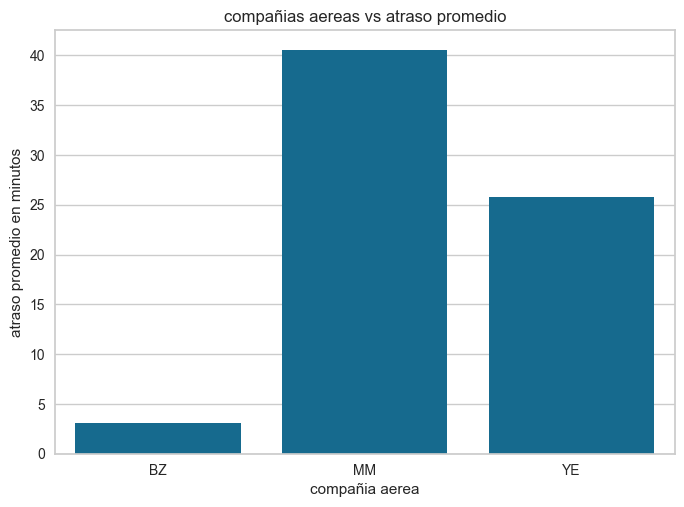

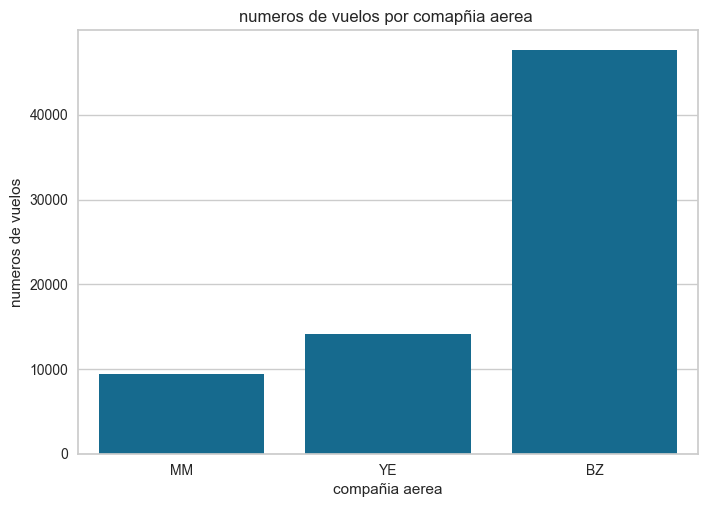

In [8]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y= 'delay', data=avg_delay)
plt.title('compañias aereas vs atraso promedio')
plt.xlabel('compañia aerea')
plt.ylabel('atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='airline')
plt.title('numeros de vuelos por comapñia aerea ')
plt.xlabel('compañia aerea')
plt.ylabel('numeros de vuelos')
plt.show()


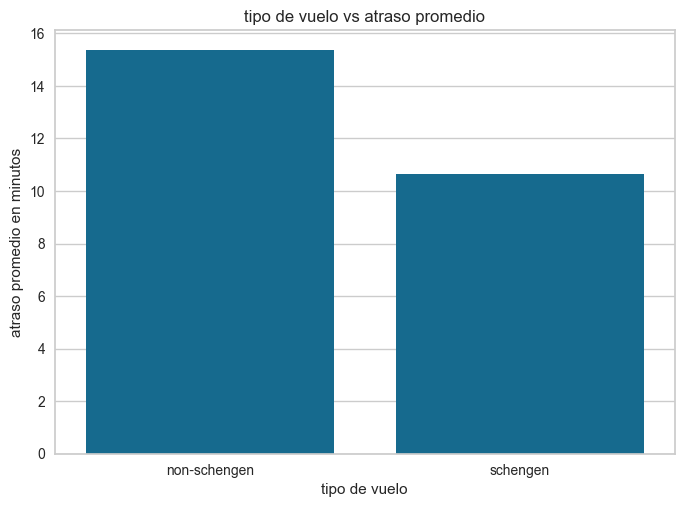

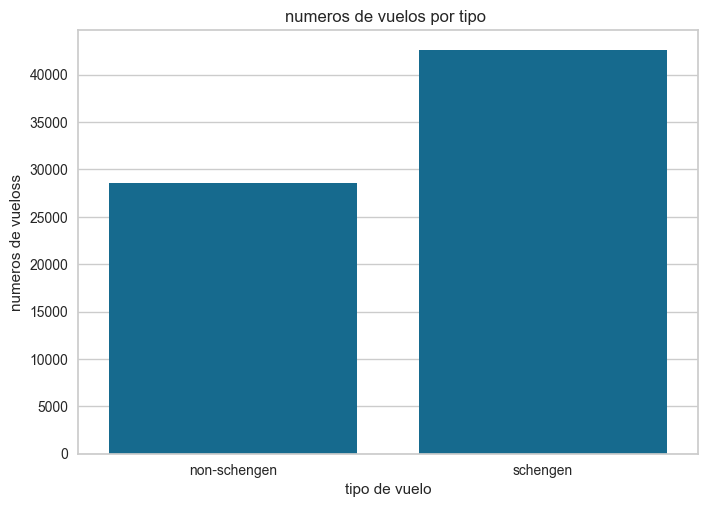

In [9]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y= 'delay', data=avg_delay)
plt.title('tipo de vuelo vs atraso promedio')
plt.xlabel('tipo de vuelo')
plt.ylabel('atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='schengen')
plt.title('numeros de vuelos por tipo ')
plt.xlabel('tipo de vuelo')
plt.ylabel('numeros de vueloss')
plt.show()

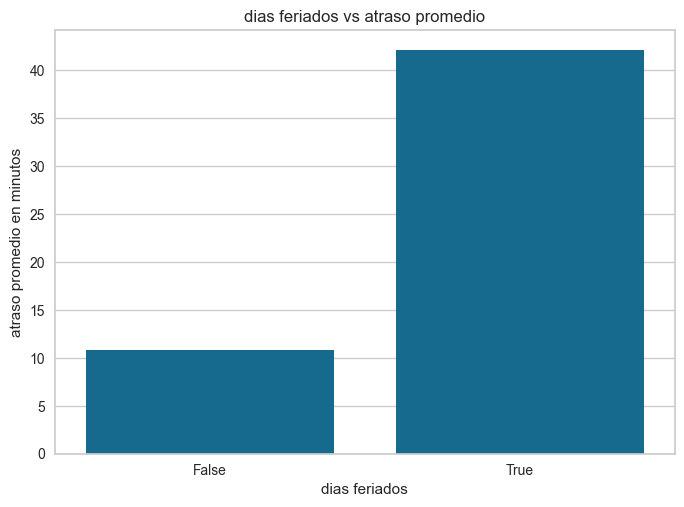

In [10]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y= 'delay', data=avg_delay)
plt.title('dias feriados vs atraso promedio')
plt.xlabel('dias feriados')
plt.ylabel('atraso promedio en minutos')
plt.show()

In [11]:
order = datos['aircraft_type'].value_counts()#.index
order

#['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175','Boeing 737', 'Boeing 777']

aircraft_type
Airbus A320     30778
Airbus A330     16654
Boeing 787       9606
Embraer E175     7098
Boeing 737       4722
Boeing 777       2317
Name: count, dtype: int64

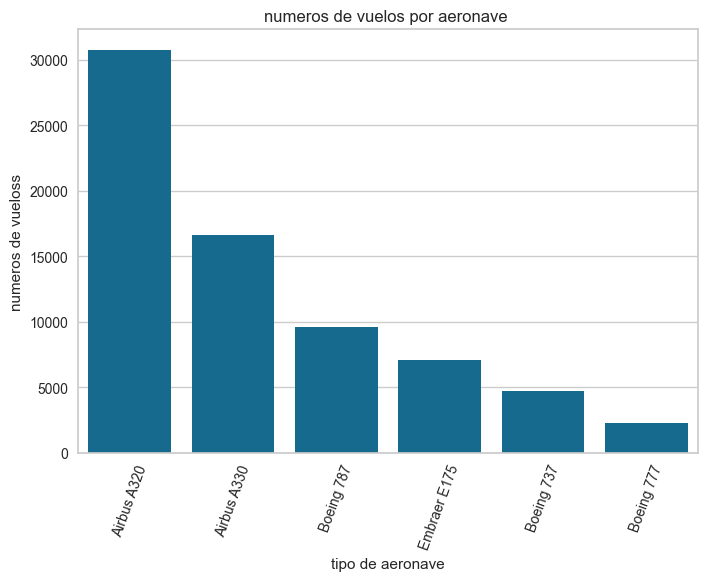

In [12]:
order = datos['aircraft_type'].value_counts().index

sns.countplot(data=datos, x='aircraft_type', order=order)
plt.title('numeros de vuelos por aeronave ')
plt.xticks(rotation=70)
plt.xlabel('tipo de aeronave')
plt.ylabel('numeros de vueloss')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

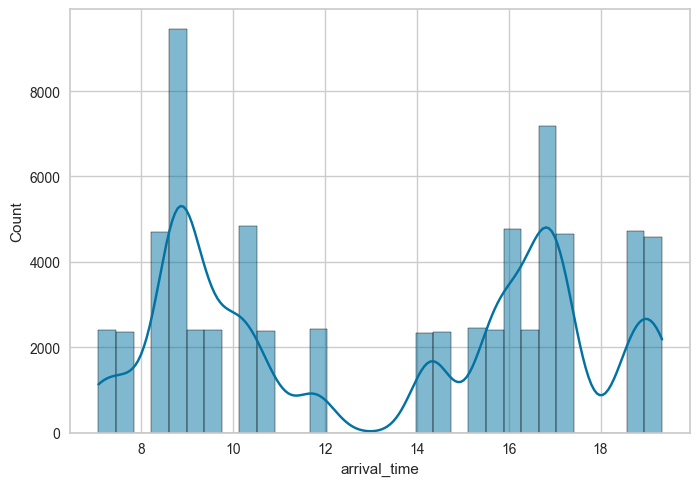

In [13]:
sns.histplot(data = datos, x='arrival_time', kde=True)

In [14]:
import numpy as np


def ancho_bin (df, columna):
    q75, q25 = np.percentile(df[columna], [75, 25])
    iqr = q75 - q25
    ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
    return ancho

<Axes: xlabel='arrival_time', ylabel='Count'>

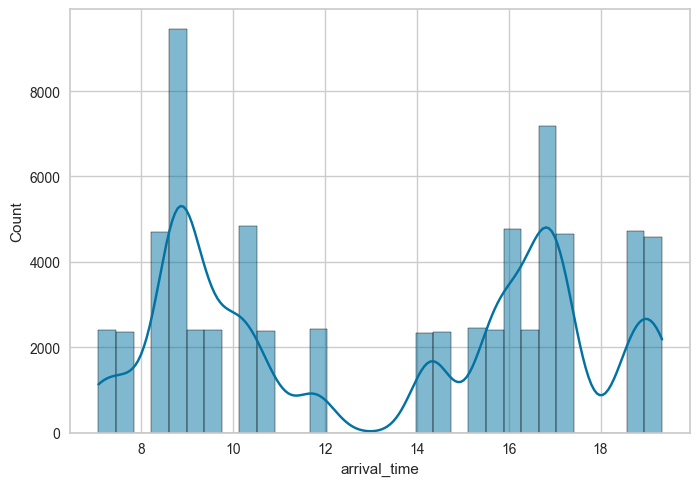

In [15]:
binwidth = ancho_bin(datos, 'arrival_time')
sns.histplot(data = datos, x='arrival_time', kde=True,binwidth=binwidth)



<Axes: xlabel='arrival_time', ylabel='Count'>

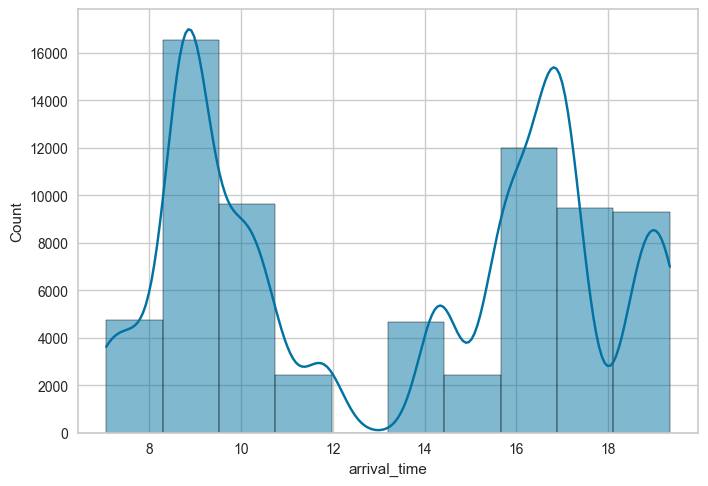

In [16]:

sns.histplot(data = datos, x='arrival_time', kde=True,bins=10)

<Axes: xlabel='departure_time', ylabel='Count'>

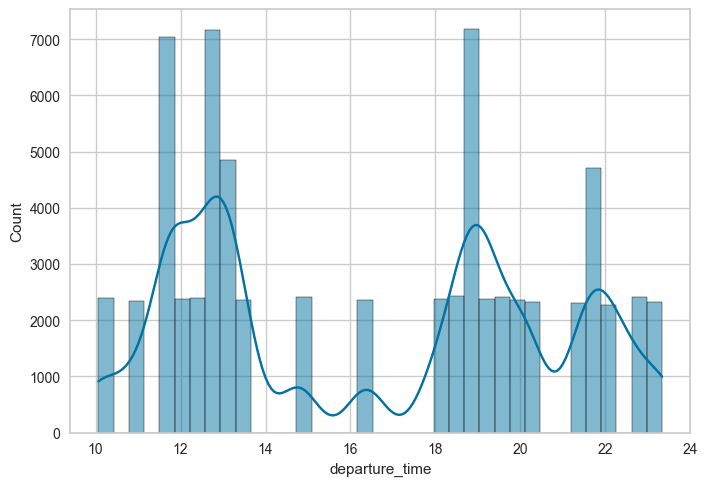

In [17]:
binwidth = ancho_bin(datos, 'departure_time')
sns.histplot(data = datos, x='departure_time', kde=True,binwidth=binwidth)

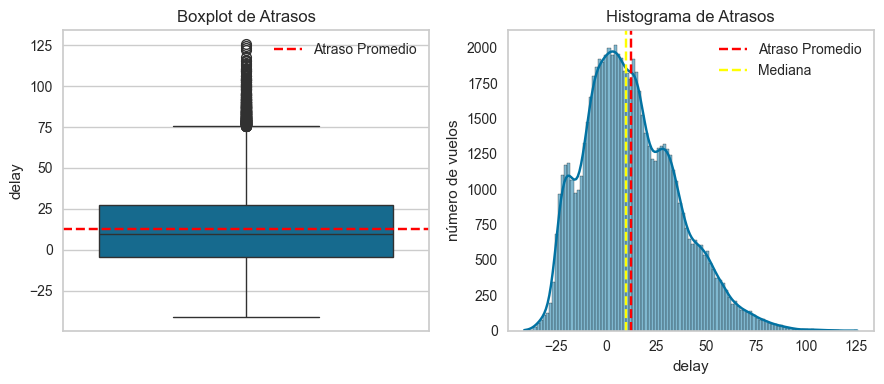

In [18]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

fig, ax = plt.subplots(1,2, figsize=(9, 4))

sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot de Atrasos')
ax[0].axhline(y= atraso_promedio, color='red', linestyle='--', label='Atraso Promedio')
ax[0].legend()

binwidth = ancho_bin(datos, 'delay')
sns.histplot(data=datos, x='delay', kde=True, ax=ax[1],binwidth=binwidth)
plt.ylabel('número de vuelos')
plt.grid(False)
ax[1].set_title('Histograma de Atrasos')
ax[1].axvline(x=atraso_promedio, color='red', linestyle='--', label='Atraso Promedio')
ax[1].axvline(x=atraso_mediana, color='yellow', linestyle='--', label='Mediana')
ax[1].legend()

plt.tight_layout()

plt.show()


In [19]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [20]:
#creacion columna date
datos['date'] = datos['year'].astype(str) + '-' +( datos['day']+1).astype(str)
datos['date'] = pd.to_datetime(datos['date'], format='%Y-%j')
datos.tail()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277,2022-12-31
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348,2022-12-31
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080,2022-12-31
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [21]:
#creacion columna fin de semana

datos['is_weekend'] = datos['date'].dt.weekday.isin([5, 6])
datos['day_name'] = datos['date'].dt.day_name()
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
69441,2,BZ,Airbus A320,schengen,ZQO,19.196804,22.196804,249,2022,False,0.472826,2022-09-07,False,Wednesday
48179,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,291,2018,False,3.275988,2018-10-19,False,Friday
68358,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,177,2022,True,10.512938,2022-06-27,False,Monday
44563,19,MM,Airbus A320,schengen,TZF,16.245220,19.245220,50,2018,False,48.680288,2018-02-20,False,Tuesday
13520,9,BZ,Airbus A330,non-schengen,TZF,10.733469,12.733469,171,2012,False,-20.086270,2012-06-20,False,Wednesday


In [22]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [23]:
datos ['schengen'] = datos['schengen'].replace({'non-schengen':0, 'schengen':1})
datos ['is_holiday'] = datos['is_holiday'].replace({False:0, True:1})
datos ['is_weekend'] = datos['is_weekend'].replace({False:0, True:1})
datos.sample(5)

C:\Users\yuri1\AppData\Local\Temp\ipykernel_11624\1246885305.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos ['schengen'] = datos['schengen'].replace({'non-schengen':0, 'schengen':1})
C:\Users\yuri1\AppData\Local\Temp\ipykernel_11624\1246885305.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos ['is_holiday'] = datos['is_holiday'].replace({False:0, True:1})
C:\Users\yuri1\AppData\Local\Temp\ipykernel_11624\1246885305.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a futu

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
33386,1,BZ,Airbus A320,0,CNU,15.496519,18.496519,35,2016,0,25.889261,2016-02-05,0,Friday
45647,30,BZ,Embraer E175,1,PUA,8.923441,12.923441,123,2018,0,-12.424438,2018-05-04,0,Friday
56512,9,BZ,Airbus A330,0,TZF,10.733469,12.733469,117,2020,0,-20.893918,2020-04-27,0,Monday
34496,29,BZ,Boeing 737,1,ZQO,8.591208,11.591208,109,2016,0,-0.367880,2016-04-19,0,Tuesday
28512,27,BZ,Airbus A320,1,AUZ,14.376052,16.376052,75,2015,0,-3.636386,2015-03-17,0,Tuesday


In [24]:
import warnings 

warnings.filterwarnings('ignore')

In [25]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  int64         
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  int64         
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  int64         
 13  day_name        71175 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(6), object(4)


In [26]:
categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

pd.get_dummies(datos, columns=categoricas, dtype=int)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,3,1,18.635384,22.635384,364,2022,1,25.677277,2022-12-31,1,...,0,1,0,0,0,1,0,0,0,0
71171,17,0,16.718722,21.718722,364,2022,1,52.624348,2022-12-31,1,...,0,0,0,0,0,1,0,0,0,0
71172,7,1,8.564949,13.564949,364,2022,1,56.167080,2022-12-31,1,...,0,1,0,0,0,1,0,0,0,0
71173,5,1,9.344097,12.344097,364,2022,1,56.758844,2022-12-31,1,...,0,0,1,0,0,1,0,0,0,0


In [27]:
datos_codificados = pd.get_dummies(data = datos, columns=categoricas, dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
69634,17,0,16.718722,21.718722,262,2022,0,-3.455669,2022-09-20,0,...,0,0,0,0,0,0,0,0,1,0
23753,1,0,15.496519,18.496519,123,2014,0,6.059206,2014-05-04,1,...,0,0,0,0,0,0,1,0,0,0
55530,26,0,8.885071,10.885071,52,2020,0,32.139852,2020-02-22,1,...,1,0,0,0,0,1,0,0,0,0
51017,21,1,7.065594,10.065594,116,2019,0,12.498225,2019-04-27,1,...,0,0,0,0,0,1,0,0,0,0
4043,28,0,15.967963,17.967963,269,2010,0,-10.130144,2010-09-27,0,...,0,0,0,0,1,0,0,0,0,0


In [28]:
datos[['arrival_time', 'departure_time']].corr()


,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [29]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [30]:
df = datos_codificados.drop(columns=['flight_id', 'departure_time', 'day', 'year', 'date'])
df.sample(10)


,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
9773,1,18.801235,0,41.739891,0,0,0,1,0,0,...,1,0,0,1,0,0,0,0,0,0
2798,1,8.591208,0,-2.755302,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
59117,1,16.909690,0,7.088701,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
20590,1,16.909690,0,21.033671,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
30752,0,16.571894,0,1.249533,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
18402,0,10.177197,0,4.823295,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
29103,1,18.635384,0,-17.048053,1,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
27346,1,8.591208,0,22.634602,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
19875,0,8.794147,0,66.157767,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
11231,0,15.967963,0,-6.417639,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   schengen                    71175 non-null  int64  
 1   arrival_time                71175 non-null  float64
 2   is_holiday                  71175 non-null  int64  
 3   delay                       71175 non-null  float64
 4   is_weekend                  71175 non-null  int64  
 5   airline_BZ                  71175 non-null  int64  
 6   airline_MM                  71175 non-null  int64  
 7   airline_YE                  71175 non-null  int64  
 8   aircraft_type_Airbus A320   71175 non-null  int64  
 9   aircraft_type_Airbus A330   71175 non-null  int64  
 10  aircraft_type_Boeing 737    71175 non-null  int64  
 11  aircraft_type_Boeing 777    71175 non-null  int64  
 12  aircraft_type_Boeing 787    71175 non-null  int64  
 13  aircraft_type_Embraer E175  711

### CLASE 3 ###

In [32]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X = df.drop(['delay'], axis=1)
y = df['delay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

baseline = DummyRegressor()

baseline.fit(X_train, y_train)


DummyRegressor()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred_dummy = baseline.predict(X_test)

def calcular_regresion(y_test,y_pred):
    rmse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    metricas = {
        'RMSE': round(rmse**(1/2),4),  # Ajuste del RMSE
        'MAE' : round(mae,4),
        'R2'  : round(r2,4)
    }
    return metricas

In [34]:
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
resultados_baseline

{'RMSE': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

In [35]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)
ypred = modelo.predict(X_test)
reultados_rf = calcular_regresion(y_test, ypred)
reultados_rf



{'RMSE': 13.7479, 'MAE': 11.0262, 'R2': 0.6477}

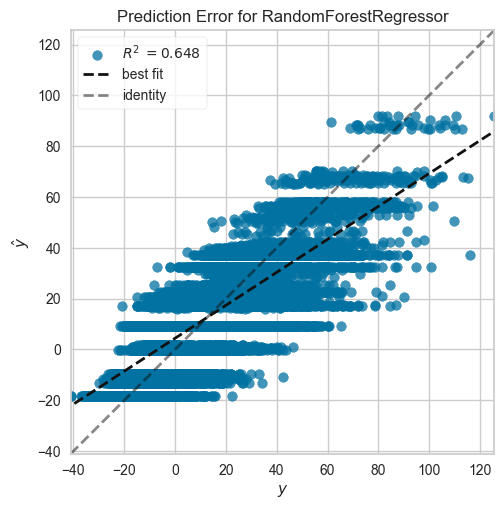

In [36]:

from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test);


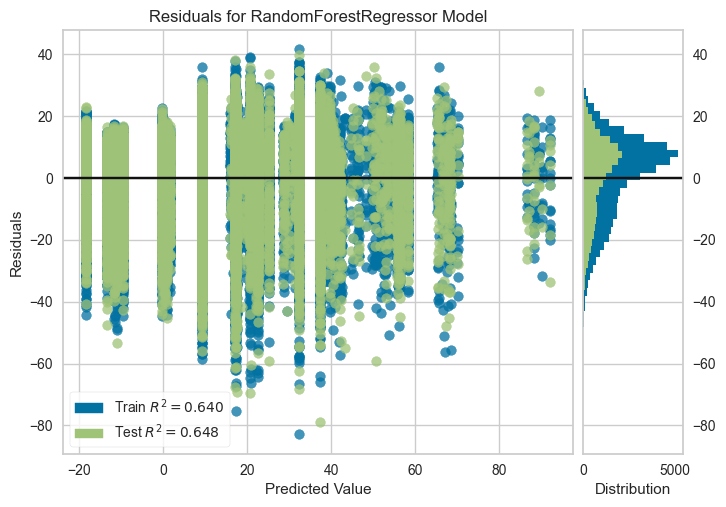

In [37]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo, X_train, y_train, X_test, y_test);


In [38]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}




cv =KFold(n_splits=5, shuffle=True , random_state=422)
cv_results = cross_validate(modelo, X_train, y_train, cv=cv, scoring= scoring)
cv_results

{'fit_time': array([1.80751562, 1.82066631, 1.82420683, 1.81165481, 1.81488919]),
 'score_time': array([0.03635287, 0.03634357, 0.03526139, 0.03561091, 0.03367519]),
 'test_RMSE': array([-14.00402747, -13.78911847, -14.05739453, -13.81131643,
        -13.76237719]),
 'test_MAE': array([-11.23801803, -11.03640214, -11.30287542, -11.09276329,
        -11.08758322]),
 'test_R2': array([0.6349385 , 0.63671818, 0.6352626 , 0.63815904, 0.64973053])}

### CLASE 4 ###

In [39]:
len(df.columns)

31

In [40]:
importances =  modelo.feature_importances_

In [41]:
feature_importances = pd.DataFrame({'Features': X.columns, 'Importances':(importances*100).round(2)}).sort_values(by='Importances', ascending=False)
feature_importances

,Features,Importances
4,airline_BZ,53.03
2,is_holiday,14.59
7,aircraft_type_Airbus A320,10.07
8,aircraft_type_Airbus A330,5.76
12,aircraft_type_Embraer E175,4.59
1,arrival_time,3.60
11,aircraft_type_Boeing 787,2.64
20,origin_TCY,2.09
15,origin_CSF,1.60
19,origin_PUA,1.03


In [42]:
[i if i != 0 else 1 for i in range(0,35,5)]

[1, 5, 10, 15, 20, 25, 30]

In [43]:
resultados = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

for i in ct_features:
    select_features = feature_importances['Features'].values[:i]
    X_train_sel = X_train[select_features]
    X_test_sel = X_test[select_features]
    model_features.fit(X_train_sel, y_train)
    y_pred = model_features.predict(X_test_sel)
    metricas = calcular_regresion(y_test, y_pred)
    resultados[i] = list(metricas.values())
    
resultados

,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7587,13.7497,13.7498,13.7477,13.7479
MAE,14.9620,12.0605,11.0422,11.0285,11.0280,11.0261,11.0262
R2,0.3388,0.5718,0.6471,0.6476,0.6476,0.6477,0.6477


In [44]:
resultados = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = range(10,16)

for i in ct_features:
    select_features = feature_importances['Features'].values[:i]
    X_train_sel = X_train[select_features]
    X_test_sel = X_test[select_features]
    model_features.fit(X_train_sel, y_train)
    y_pred = model_features.predict(X_test_sel)
    metricas = calcular_regresion(y_test, y_pred)
    resultados[i] = list(metricas.values())
    
resultados

,10,11,12,13,14,15
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476


In [45]:
select_features = feature_importances['Features'].values[:13]
X_selected_features = X[select_features]
X_selected_features

,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,aircraft_type_Boeing 787,origin_TCY,origin_CSF,origin_PUA,origin_TZF,day_name_Friday,origin_MWL
0,0,0,1,0,0,8.885071,0,1,0,0,0,1,0
1,0,0,1,0,0,8.939996,0,1,0,0,0,1,0
2,1,0,0,0,1,18.635384,0,0,0,0,1,1,0
3,1,0,0,1,0,15.967963,0,0,0,0,0,1,0
4,1,0,0,1,0,16.571894,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1,1,0,0,1,18.635384,0,0,0,0,1,0,0
71171,1,1,0,1,0,16.718722,0,0,0,0,0,0,0
71172,0,1,0,0,0,8.564949,1,0,0,0,1,0,0
71173,1,1,1,0,0,9.344097,0,0,0,0,0,0,0


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features, y, random_state=42)   

In [47]:
param_grid = {
                'max_depth': [5, 10, 15],
                'min_samples_leaf': [1, 2, 3],
                'min_samples_split': [2, 4, 6],
                'n_estimators': [100, 150, 200]
            }



### tiempo de resultado como 10 min ###

In [48]:
from sklearn.model_selection import GridSearchCV

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=param_grid, scoring='r2',  cv=cv)

model_grid.fit(X_train,y_train)



GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [49]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [50]:
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test, y_pred_grid)
metricas_model_grid

{'RMSE': 13.2308, 'MAE': 10.6296, 'R2': 0.6754}

In [51]:
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,10,11,12,13,14,15,modelo_grid
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497,13.2308
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285,10.6296
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476,0.6754


In [52]:
import pickle

try:
    with open('champion.pkl', 'wb') as file:
        pickle.dump(model_grid.best_estimator_, file)
    print("Modelo guardado exitosamente como 'champion.pkl'")
except Exception as e:
    print(f"Error al guardar el modelo:",str(e))

Modelo guardado exitosamente como 'champion.pkl'


Concluimos el proceso de desarrollo, optimización y guardado del modelo. Sin embargo, surge la cuestión de cómo utilizar efectivamente este modelo en situaciones prácticas. ¿Cómo podemos aprovechar el modelo que fue guardado para realizar predicciones actualizadas?

Ante esto, construye un código que cargue el modelo guardado y realice la predicción para la siguiente muestra:

In [53]:
import pickle

In [54]:
file_path = 'champion.pkl'

try:
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    print("¡Modelo cargado con éxito!")
except Exception as e:
    print("Ocurrió un error al cargar el modelo:", str(e))

¡Modelo cargado con éxito!


In [55]:
nueva_muestra = [0.0, 10.8941, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [56]:
# Ejemplo de predicción con datos de entrada 'X'
model.predict([nueva_muestra])[0]

np.float64(48.73321005358915)